In [1]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o", temperature=1)


In [2]:
#building workflow in LangGraph
from typing_extensions import TypedDict #for entire State
from langchain_core.messages import AnyMessage #human or AI message
from typing import Annotated  #labeling
from langgraph.graph.message import add_messages #add messages is reducer in langgraph
from IPython.display import display,Image
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [3]:
# 1. Define the State clearly
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [4]:
from langchain_core.messages.utils import convert_to_openai_messages
def Superbot(state: State):
    # Automatically handles roles, tool calls, and content blocks
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [ ]:
from langchain_core.messages import HumanMessage

In [7]:
#for adding memory in langgraph
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

# 2. Build the graph
builder = StateGraph(State)
builder.add_node("Superbot", Superbot)

builder.add_edge(START, "Superbot")
builder.add_edge("Superbot", END)
graph_builder = builder.compile(checkpointer=memory)



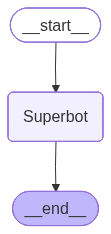

In [9]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))    

In [10]:
#provided thread id
config={"configurable":{"thread_id":"Supermemory"}}


In [13]:
temp_message = graph_builder.invoke(
{"messages": " My name is Parth and I like Cricket?"},config=config
)

In [14]:
temp_message

{'messages': [HumanMessage(content=' My name is Parth and I like Cricket?', additional_kwargs={}, response_metadata={}, id='f3324f8a-5d4c-4502-ab9c-d8433f3af84b'),
  AIMessage(content="Hi Parth! It's great to hear that you like cricket. It's such an exciting sport with a rich history. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 17, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Cz25gX2mCOgtXPaW1jpZrf1t9Sc7T', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bcc79-963d-7fc2-92e5-8f037f282349-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

Steaming 

Methods: stream() and astream()

additional parameter in streaming modes of graph state

    - values: This streams full state of graph after each node is called
    - updates: This streams updates to the state of graph after each node is called.

In [18]:
#provided thread id
config={"configurable":{"thread_id":"1"}}

for chunk in graph_builder.stream(
    {"messages": "My name is Parth and I like Cricket?"},config=config,stream_mode="updates"
):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Parth! It's great to hear that you enjoy cricket. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 17, 'total_tokens': 43, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Cz2Fs5BK7eQ17pr9AlurRQk6I0rC8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bcc83-399e-77e3-bee0-1844a76400d1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 26, 'total_tokens': 43, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [19]:
#provided thread id
config={"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream(
    {"messages": "My name is Parth and I like Cricket?"},config=config,stream_mode="values"
):
    print(chunk)

{'messages': [HumanMessage(content='My name is Parth and I like Cricket?', additional_kwargs={}, response_metadata={}, id='289a37b7-4fa3-4917-9693-a8c50598ac8e')]}
{'messages': [HumanMessage(content='My name is Parth and I like Cricket?', additional_kwargs={}, response_metadata={}, id='289a37b7-4fa3-4917-9693-a8c50598ac8e'), AIMessage(content="Hi Parth! It's great to hear that you like cricket. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 17, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Cz2GTKcscnW437vlEeWwvPSUkVcmx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': Non

In [26]:
#provided thread id
config={"configurable":{"thread_id":"3"}}

async for chunk in graph_builder.astream_events({"messages": [("user","My name is Parth and I like Cricket")]},
                                          config=config,version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': [('user', 'My name is Parth and I like Cricket')]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019bcc8c-c200-7ef2-a40f-8f90a8b15e5b', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='My name is Parth and I like Cricket', additional_kwargs={}, response_metadata={}, id='18763361-0ae8-4246-81fd-af1e7398b9b7')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019bcc8c-c204-7832-a72a-17c633ff7d9d', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:3ab4c7b5-4b95-4a46-e872-8fa6f4a17c06'}, 'parent_ids': ['019bcc8c-c200-7ef2-a40f-8f90a8b15e5b']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='My name is Parth and I like Cricket', additional_